# HW1: Graph Basics and Properties

In this assignment I will learn to ceate, modify, and analyze graphs using Python's NetworkX library.

# Part A- Graph Creation and Modification



## Q1: Graph Creation
Create the undirected graph and show vizualization of the graph

In [ ]:
# makke the graph
import networkx as nx
import matplotlib.pyplot as plt

# create empty undirected graph
G = nx.Graph()

# add edges
edges = [
    (0,5), (0,4), (0,1),
    (5,7), (5,4),
    (7,9), (7,2),
    (2,1), (2,3),
    (3,8), (3,4),
    (4,9), (4,8),
    (6,8), (6,1), (6,9)

]
G.add_edges_from(edges)

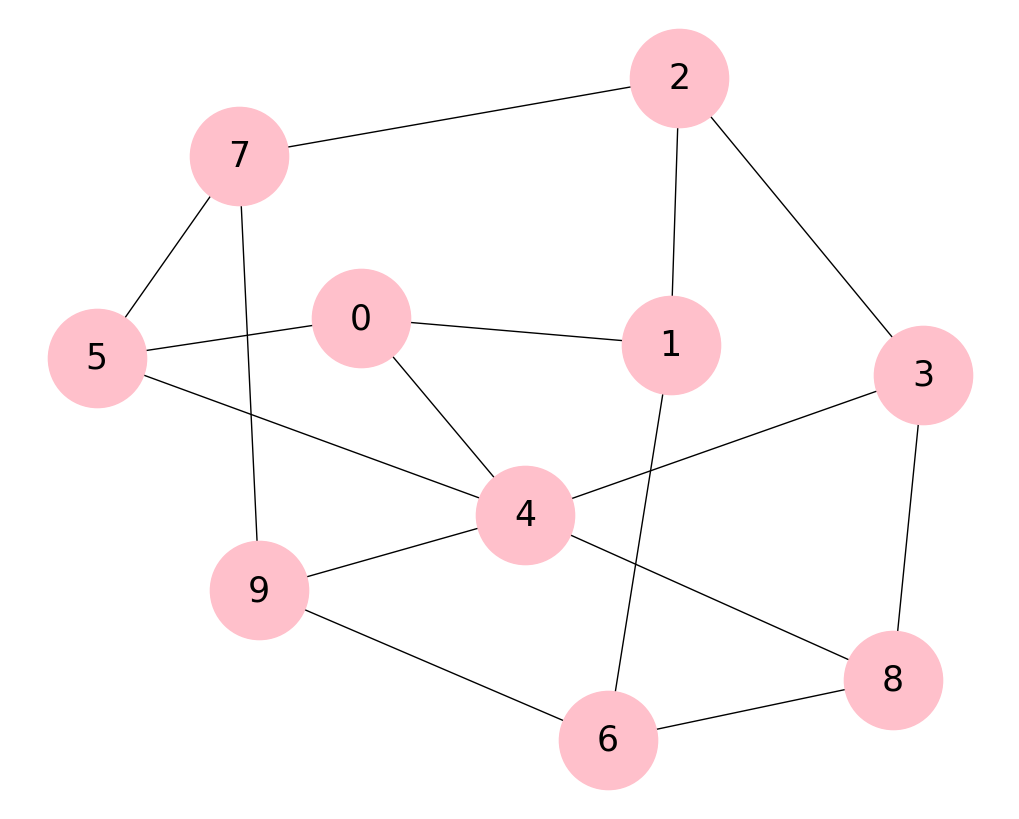

In [ ]:
# visualize the graph
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color='pink',
        node_size=5000, font_size=25)

## Q2: Graph Modification
Based on graph created in Q1, remove node 1, edge (0,4) and edge (0,5). List remaining components and visualize remaining graph

In [ ]:
# copy graph
G2 =  G.copy()

# remove node 1 and edges (0,4) and (0,5)
G2.remove_node(1)
G2.remove_edge(0,4)
G2.remove_edge(0,5)

# list remanining components
print("remaining nodes:", list(G2.nodes()))
print("remaining edges:", list(G2.edges()))
print("remaining components", list(nx.connected_components(G2)))

remaining nodes: [0, 5, 4, 7, 9, 2, 3, 8, 6]
remaining edges: [(5, 7), (5, 4), (4, 3), (4, 9), (4, 8), (7, 9), (7, 2), (9, 6), (2, 3), (3, 8), (8, 6)]
remaining components [{0}, {2, 3, 4, 5, 6, 7, 8, 9}]


Text(0.5, 1.0, 'Modified Graph')

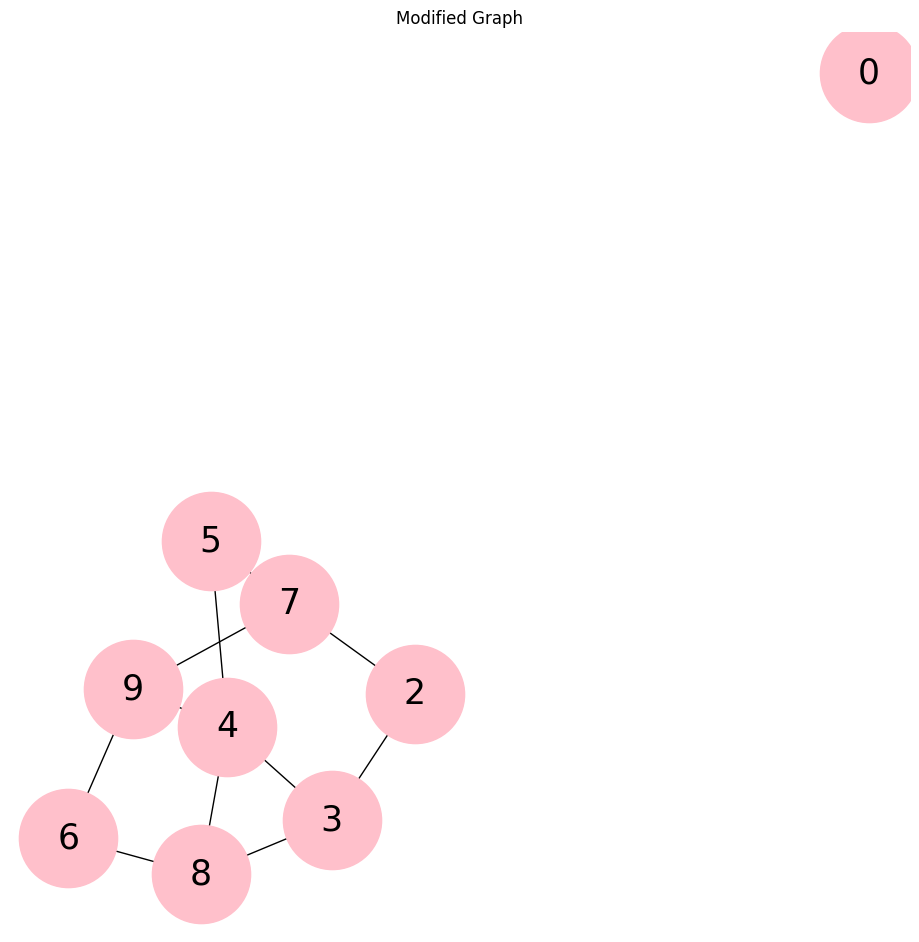

In [ ]:
# visualize the graph
plt.figure(figsize=(9, 9))
nx.draw(G2, with_labels=True, node_color='pink', node_size=5000, font_size=25)
plt.title("Modified Graph")

# Part B- Graph Essentials and Measures


## Q3: Graph Creation
Create undirected graph using edge list file from graph.txt. Report node and edge numbers and number of connected components

In [ ]:
# create undirected graph from edge list
G3 = nx.read_edgelist('graph.txt')

# print node, edge numbers, and number of connected components
print(f"nodes: {G3.number_of_nodes()}")
print(f"edges: {G3.number_of_edges()}")
print(f"connected components: {nx.number_connected_components(G3)}")


nodes: 26728
edges: 26377
connected components: 4104


## Q4: Graph Essentials
Based on the created graph, get the largest connected component, report node and edge number of this component. Show visualization of the 2nd largest connected component. Plot degree distribution of the whole graph.

In [ ]:
# get largest connected component
largest_connected_component = max(nx.connected_components(G3), key=len)
#convert to a subgraph to call methods
G3_subgraph = G3.subgraph(largest_connected_component)

# print node and edge number
print(f"nodes of largest connected component: {G3_subgraph.number_of_nodes()}")
print(f"edges of largest connected component:: {G3_subgraph.number_of_edges()}")

nodes of largest connected component: 13903
edges of largest connected component:: 16695


Text(0.5, 1.0, 'Largest Connected Component')

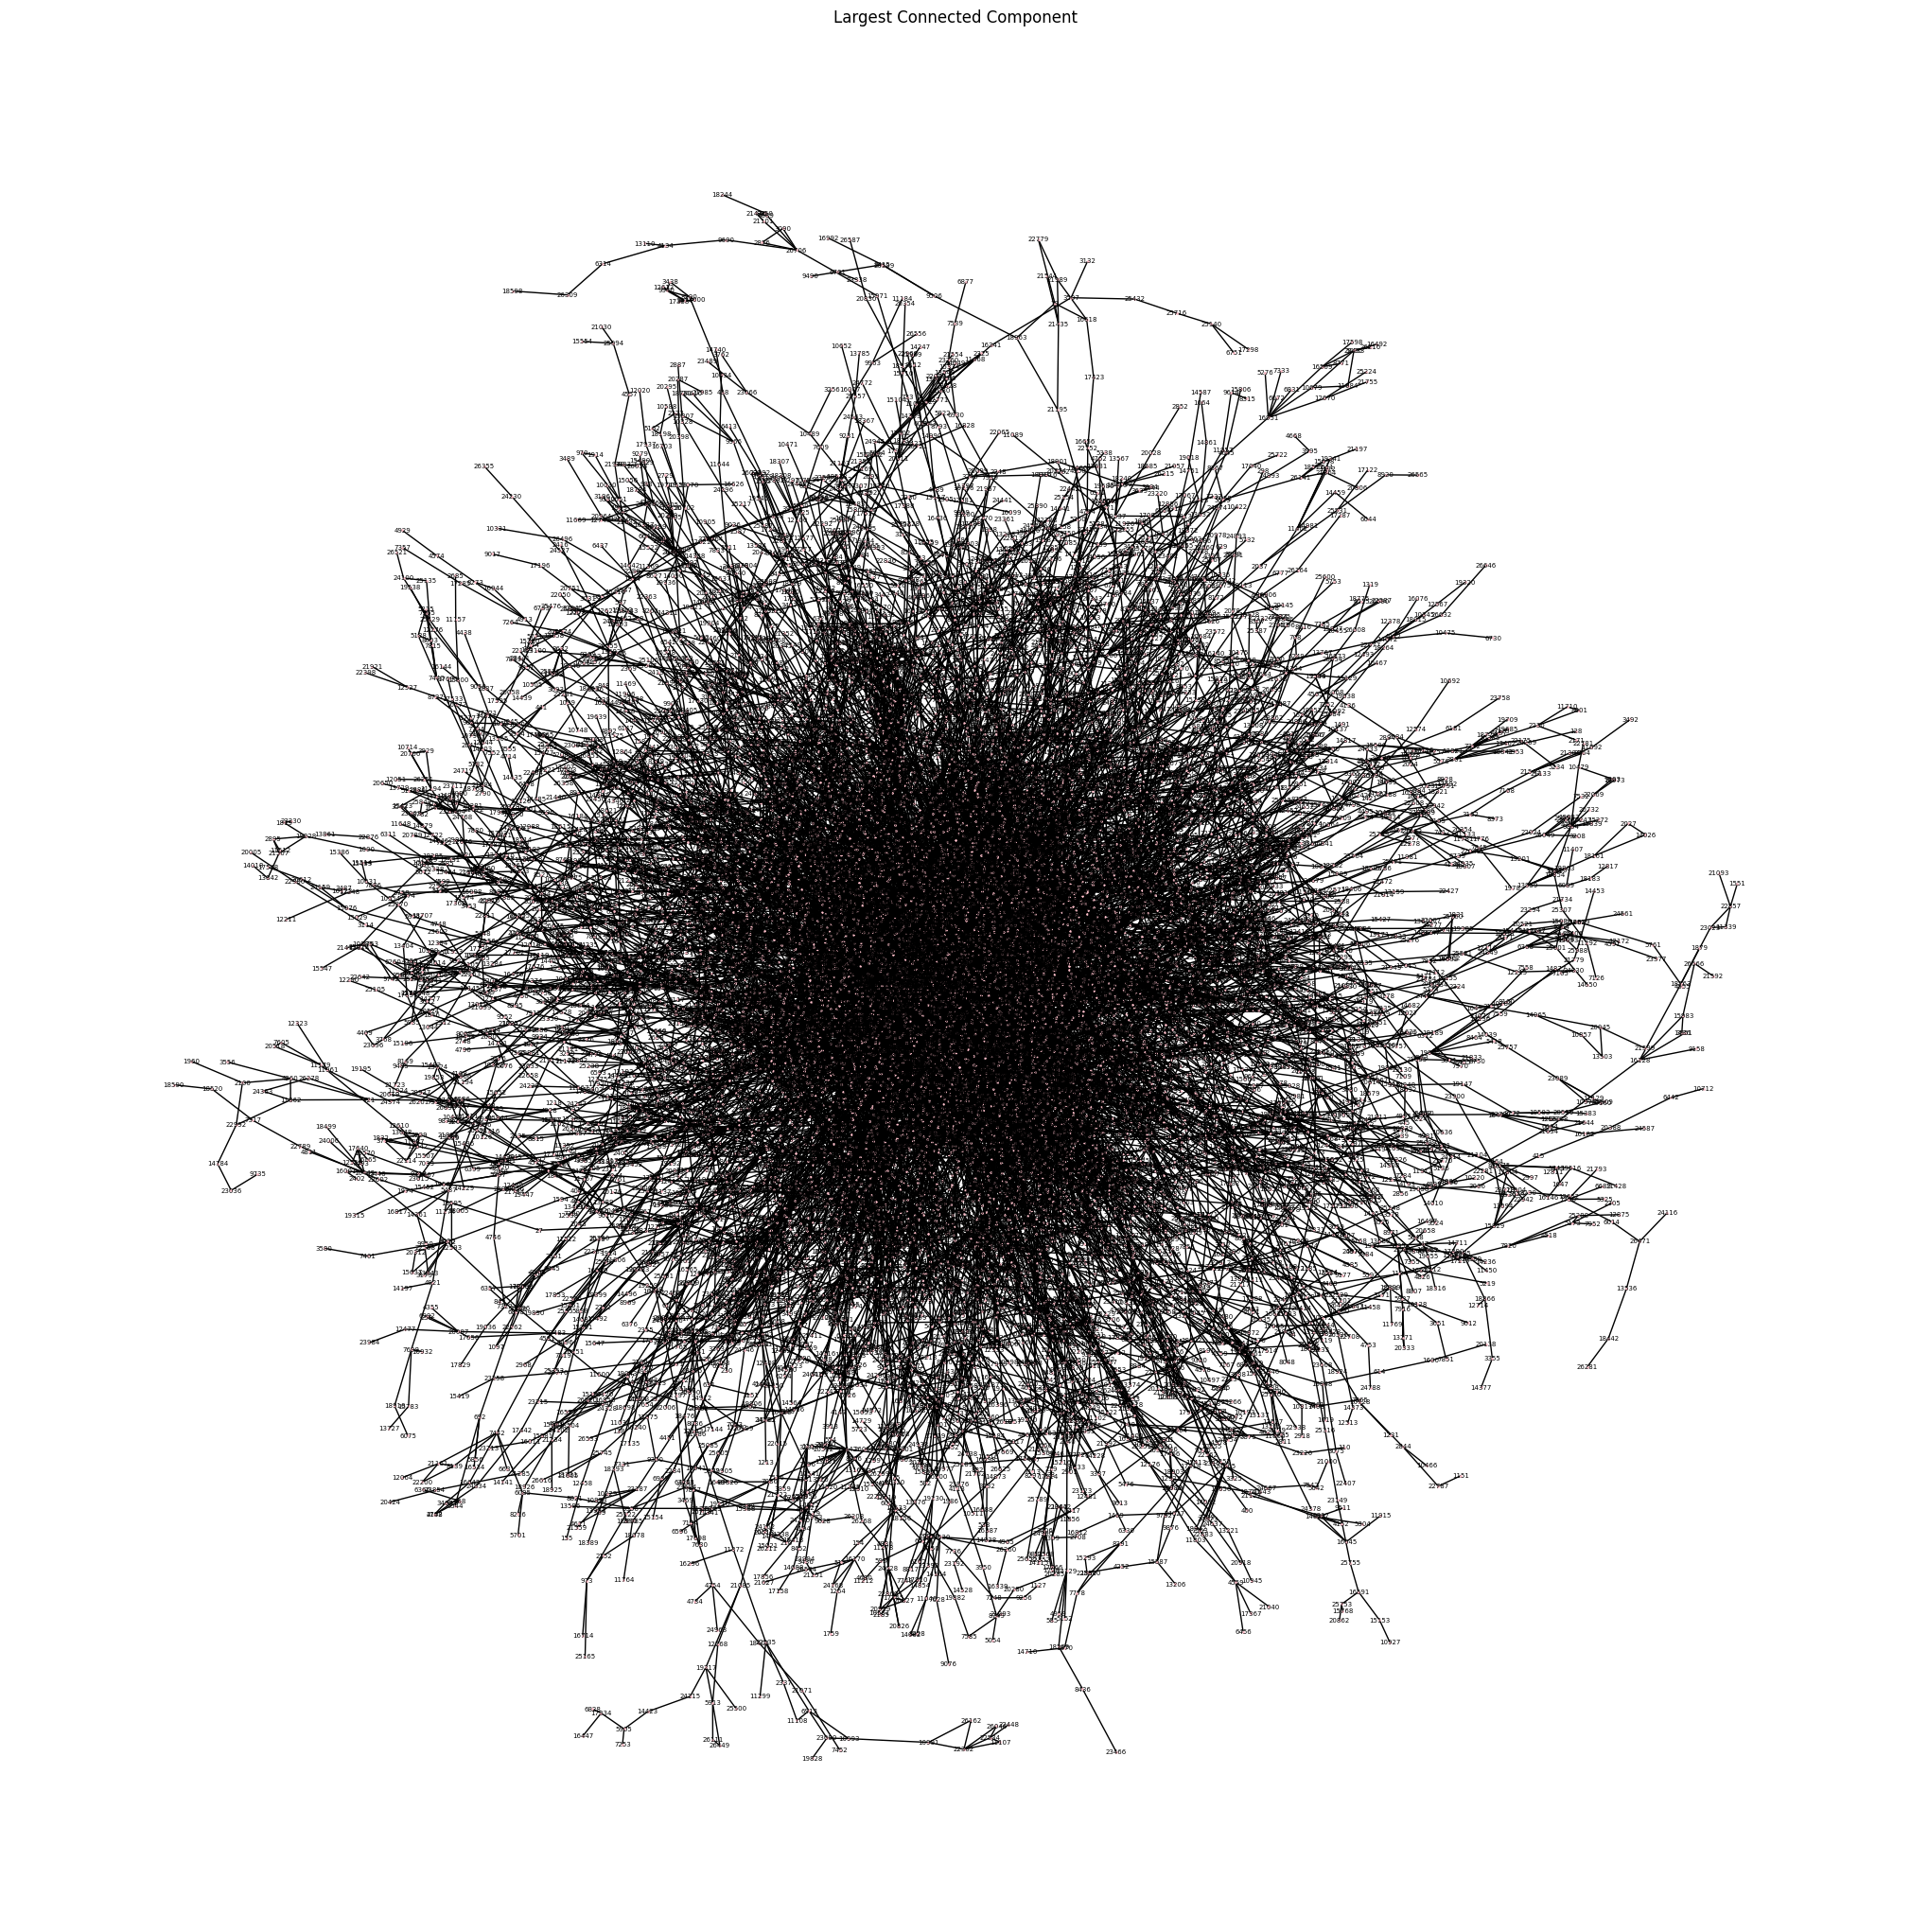

In [ ]:
# create visualization
plt.figure(figsize=(9, 9))
nx.draw(G3_subgraph, with_labels=True, node_color='pink', node_size=50, font_size=15)
plt.title("Largest Connected Component")

In [13]:
# get the 2nd largest component
# sort the omponents by size and get the 2nd one:
sorted_components = sorted(nx.connected_components(G3), key=len, reverse=True)

# get the 2nd largest component
second_largest_component = sorted_components[1]
G3_subgraph_second = G3.subgraph(second_largest_component)

# print node and edge number
print(f"nodes of 2nd largest connected component: {G3_subgraph_second.number_of_nodes()}")
print(f"edges of 2nd largest connected component:: {G3_subgraph_second.number_of_edges()}")


nodes of 2nd largest connected component: 69
edges of 2nd largest connected component:: 80


Text(0.5, 1.0, '2nd Largest Connected Component')

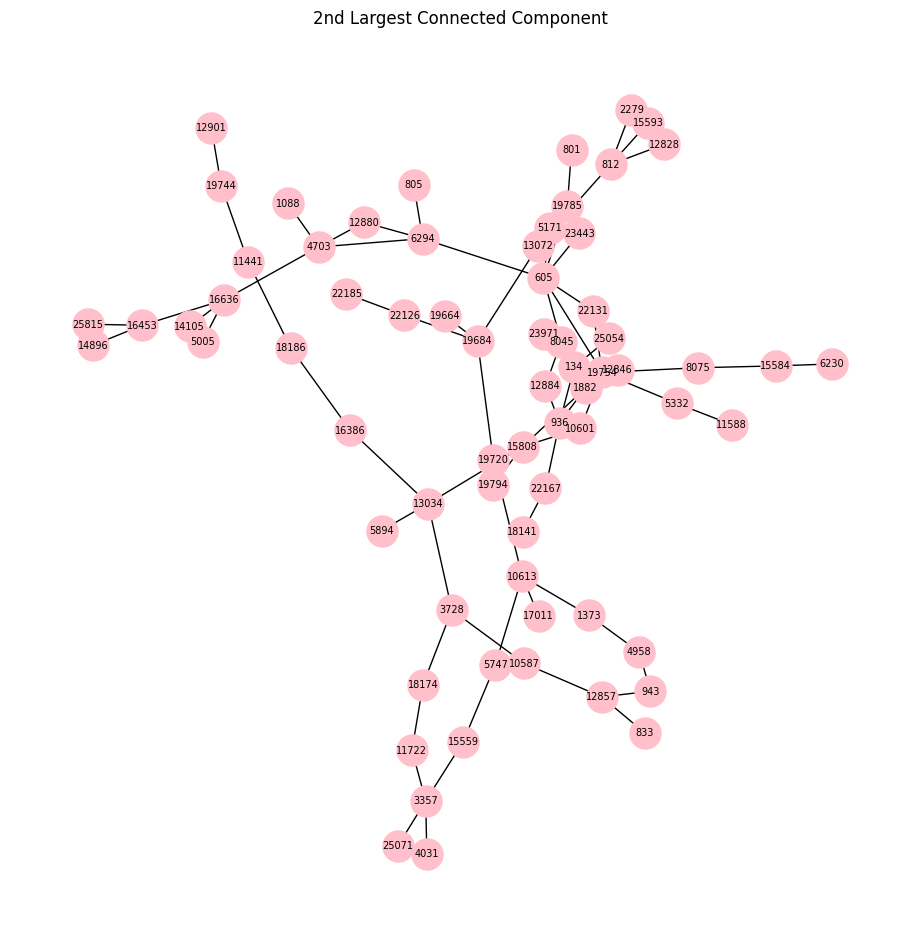

In [16]:
# visualize the 2nd largest component
plt.figure(figsize=(9, 9))
nx.draw(G3_subgraph_second, with_labels=True, node_color='pink', node_size=500, font_size=7)
plt.title("2nd Largest Connected Component")

Text(0.5, 1.0, 'Degree Distribution of G3 Graph')

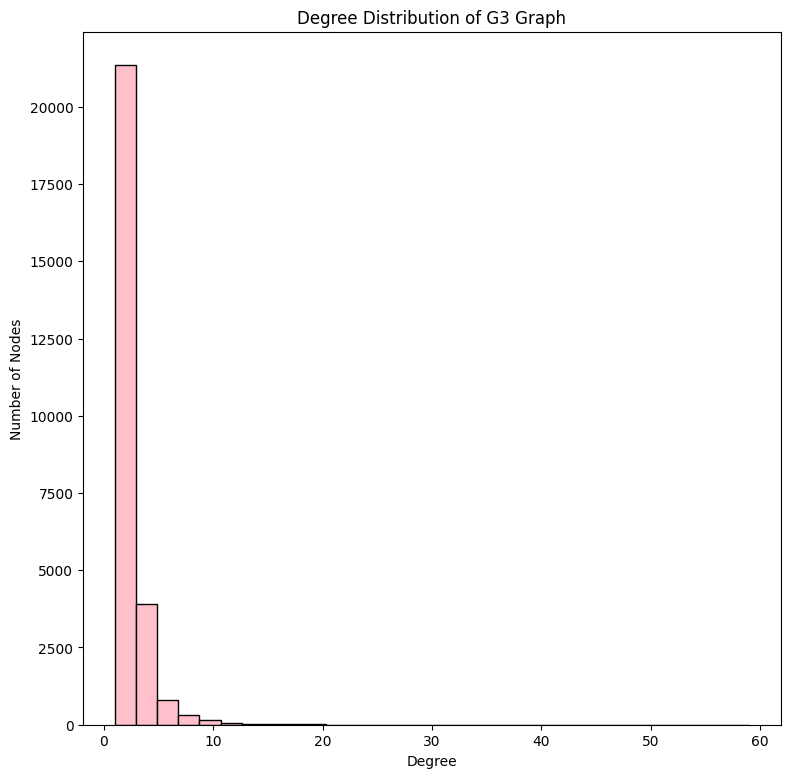

In [19]:
# plot degree distribution of the whole graph
# get degree of each node
degrees = [G3.degree(n) for n in G3.nodes()]

# create visualization
plt.figure(figsize=(9, 9))
plt.hist(degrees, bins=30, edgecolor='black', color='pink')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution of G3 Graph')

## Q5: Graph Measures
Based on the created graph in Q3:
1. generate eigenvector centrality
2. report top-10 nodes with largest eigenvector centrality using default networkx parameters
3. generate katz centrality
4. report top-10 nodes with largest katz centrality usisng default network parameters
5. report average clustering coefficient of all nodes in the graph
6. report average jaccard similarity of all connected node pairs in the graph

In [21]:
# 1 generate eigenvector centrality
# calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G3)
#print centrality sore for each node
print(f"eigenvector centrality of G3 graph: {eigenvector_centrality}")

eigenvector centrality of G3 graph: {'23298': 6.112358351059857e-05, '19054': 0.00032673979325970585, '24795': 2.725922650405502e-05, '8178': 0.00017700335272347197, '15497': 0.002767757047968798, '25141': 0.0025080970207144175, '11249': 0.002441102447758764, '18559': 0.00031969740769960473, '240': 0.018393177156553742, '17545': 5.502408809860521e-09, '2': 4.633867087483086e-08, '4157': 6.273761638270355e-10, '441': 6.528301037602229e-10, '18403': 6.357476266768004e-10, '19242': 4.0084113082153673e-07, '15009': 4.4664896593799805e-05, '2984': 5.132061328773077e-06, '23198': 0.00029333081474666175, '1486': 1.690379340315217e-05, '26581': 5.8914424010818336e-06, '9316': 5.809961756105216e-06, '9471': 5.593260107637393e-06, '6348': 5.639446061586601e-06, '4694': 5.132061328773077e-06, '16384': 5.132061328773077e-06, '13836': 4.054675077499006e-05, '13521': 9.040035328577976e-27, '8': 9.040035328577976e-27, '6441': 1.765357198768171e-05, '9': 2.022988413220401e-06, '6610': 2.82365170912868

In [29]:
# 2 report top-10 nodes with largest eigenvector
#calculate top 10
top_10_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
# print top 10 nodes with largest eigenvector centrality
print(f"top 10 nodes with the largest eigenvector centrality:")
for i, (node, centrality) in enumerate(top_10_eigenvector, 1):
    print(f"{i}. {node}: {centrality:.4f}")

top 10 nodes with the largest eigenvector centrality:
1. 16485: 0.4918
2. 22777: 0.4199
3. 14618: 0.1777
4. 21928: 0.1392
5. 2884: 0.1338
6. 1197: 0.1332
7. 9068: 0.1111
8. 17902: 0.1092
9. 1324: 0.1001
10. 25747: 0.0944


In [28]:
# 3 generate katz centrality
#calculate katz centrality
katz_centrality = nx.katz_centrality(G3)
print(f"katz centrality of G3 graph: {katz_centrality}")


katz centrality of G3 graph: {'23298': 0.005472339921117937, '19054': 0.005151376564711369, '24795': 0.005004033079521569, '8178': 0.006973218045109454, '15497': 0.008446664489971901, '25141': 0.0077613453237475975, '11249': 0.006854223422071711, '18559': 0.004604142600814788, '240': 0.02250089230166571, '17545': 0.005738109797995691, '2': 0.0050235152657272806, '4157': 0.004333288379222007, '441': 0.005630032576339548, '18403': 0.004799487764659686, '19242': 0.006902268867078177, '15009': 0.009515353690096793, '2984': 0.004711012746984749, '23198': 0.007299291804648224, '1486': 0.007157157657697141, '26581': 0.005837791630572285, '9316': 0.005294791907234645, '9471': 0.006183500331622022, '6348': 0.006117595981250096, '4694': 0.004711012746984749, '16384': 0.004711012746984749, '13836': 0.005535597232486234, '13521': 0.004177197110472471, '8': 0.004177197110472471, '6441': 0.006066784052988223, '9': 0.004366155796107203, '6610': 0.00486389343279165, '15256': 0.008423574980799623, '234

In [31]:
# 4 report top-10 nodes with largest katz centrality
#calculate top 10
top_10_katz = sorted(katz_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
# print top 10 nodes with largest katz score
print(f"top 10 nodes with the largest katz centrality:")
for i, (node, centrality) in enumerate(top_10_katz, 1):
    print(f"{i}. {node}: {centrality:.4f}")

top 10 nodes with the largest katz centrality:
1. 16485: 0.2116
2. 22777: 0.1755
3. 9068: 0.1095
4. 14618: 0.0994
5. 2884: 0.0741
6. 17902: 0.0706
7. 17546: 0.0688
8. 21928: 0.0668
9. 1197: 0.0616
10. 9740: 0.0605


In [32]:
# 5 report average clustering coefficient of all nodes in the graph
#calculate average clustering coefficient
average_clustering_coefficient = nx.average_clustering(G3)
print(f"average clustering coefficient: {average_clustering_coefficient:.4f}")

average clustering coefficient: 0.1005


In [33]:
# 6 report average jaccard similarity of all connected node pairs in the graph
#get jaccard similarity score from all node pairs
jaccard_scores = [score for _, _, score in nx.jaccard_coefficient(G3, G3.edges())]
#get average
average_jaccard = sum(jaccard_scores) / len(jaccard_scores)
#print average
print(f"average jaccard similarity: {average_jaccard:.4f}")

average jaccard similarity: 0.0413


##